## Purpose:

Identify how AI and digitalization may influence the Norwegian labor market using available job posting data.

## Research question

### AI and future skills analysis

#### Main Question

How is AI changing the Norwegian labor market, and what skills will matter in the future?

### objectives

This analysis aims to:
1. Identify AI and digital-related skills in job postings
2. Understand where these skills are demanded
3. Identify occupations and industries connected to future skills
4. Compare traditional skills with emerging digital skills

_*We analyse*_
1. How many jobs contain future-oriented skills? (AI/digital skill presence)
2. Top future-oriented skills
3. Where are digital skills demanded?
4. Which jobs require future skills?

## Define AI / Digital Skill Categories

We create skill groups like:
1. AI and MAchine Learning:
-- Artificial Intellligence
-- Machine learning
-- AI
-- Neural Network

2. Data skills
-- data analysis
-- dataanalyse
-- statistics
-- SQL
-- Python
-- analytics

3. Software and Technology
-- programming
-- software
-- development
-- cloud
-- database

4. Digital transformation
-- digitalization
-- digitalisering
-- automation
-- automatisering
-- technology

5. Traditional High-Value Skills (for comparision)
-- leadership
-- project management
-- analysis
-- management

_*Note*_
These categories are researcher-defined and may miss some relevant skills. They are used as an analytical framework, not a perfect classification.

## Load prepared data

We are using the cleaned skill-level dataset: "data/processed/skills_jobs_analysis.csv"
The previous notebooks feed into this notebook correctly

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

skills_jobs_df = pd.read_csv("../data/processed/skills_jobs_analysis.csv")

In [2]:
# check data
skills_jobs_df.head()

,job_id,skills,skill,city,category,occupation,title
0,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Arkiv,LØRENSKOG,Not classified,Not classified,Vil du være med å styrke vår informasjonsforva...
1,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Brukerstøtte,LØRENSKOG,Not classified,Not classified,Vil du være med å styrke vår informasjonsforva...
2,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Digitalisering,LØRENSKOG,Not classified,Not classified,Vil du være med å styrke vår informasjonsforva...
3,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Dokumentasjonsforvaltning,LØRENSKOG,Not classified,Not classified,Vil du være med å styrke vår informasjonsforva...
4,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Informasjonsforvaltning,LØRENSKOG,Not classified,Not classified,Vil du være med å styrke vår informasjonsforva...


In [3]:
skills_jobs_df.shape

(95324, 7)

The problem is that "occupation = Not classified" . Only ~19% of jobs had occupation classification. Most rows had missing/unknown occupation. So here we should not depend on this feature.

Our main features: 
- Skill
- Title
- category: it has some duplicates and inconsistent formatting

### 3. Inspect Digital and Technology Skills

Before defining AI-related categories, we inspect existing skills in the dataset.

Understand what skills actually exist in the dataset before creating AI/digital categories.

In [4]:
skills_jobs_df["skill"].value_counts().head(100)

skill
Omsorg          1471
Kundeservice    1396
Helse           1106
Butikk          1057
Salg             981
                ... 
Sjåfør           156
Teamleder        155
Reparasjon       155
Autorisasjon     155
Forvaltning      155
Name: count, Length: 100, dtype: int64

It shows the most common skills. Then we search for possible technology terms. 

*data-driven exploration + expert classification*
For classifying the skill:
I identified emerging digital skill groups from the observed skill vocabulary and classified them into analytical categories.
I explored the dataset, then created a classification framework based on observed skills.

_Method limitation_

Skill categories were manually created based on observed skill names.

Because job postings contain both Norwegian and English terminology,
some related skills may not be captured.

The analysis should therefore be interpreted as an indicator of
digital skill demand rather than a complete measurement.

To do that:
1. Discover technology-related skills from the dataset
2. Create a classification framework
3. Handle Norwegian + English

### later
A more advanced version would use:

NLP embeddings
clustering
language models

Example:

"Find skills semantically similar to AI."

The next step should be:

- Extract the complete skill vocabulary.
- Inspect technology-related terms manually.
- Build a transparent classification table.
- Apply the categories.

# 3. Exploring the Skill Vocabulary

Before identifying AI and digital skills, we first examine the existing skill vocabulary.

The purpose is to avoid imposing an external definition of AI skills too early.

The categories will be created after observing the actual skills appearing in Norwegian job postings.

In [5]:
# check the number of unique skills (size of the vocabulary)
skills_jobs_df["skill"].nunique()

10997

In [6]:
skills_jobs_df["skill"].value_counts() # gets the vocabulary

skill
Omsorg            1471
Kundeservice      1396
Helse             1106
Butikk            1057
Salg               981
                  ... 
Telemetri            1
Elkontroll           1
Chief Engineer       1
Kommisjonering       1
Skipsdrift           1
Name: count, Length: 10997, dtype: int64

In [7]:
# view the most common- Understand the dominant skill landscape
skills_jobs_df["skill"].value_counts().head(100)

skill
Omsorg          1471
Kundeservice    1396
Helse           1106
Butikk          1057
Salg             981
                ... 
Sjåfør           156
Teamleder        155
Reparasjon       155
Autorisasjon     155
Forvaltning      155
Name: count, Length: 100, dtype: int64

Search the vocabulary manually (not classification):
We create a temprary exploration search.

#### Create a skill vocabulary table
Instead of manually searching words: Use clustering/embeddings, text similarity
- input: skill name
- convert skills into embeddings
- modl groupd similar concepts

use job titles as validation
then create the final category

_For Notebook_
I used unsupervised grouping of skill descriptions to identify emerging digital skill domains, then analyzed their demand across Norwegian job postings.
Using embeddings/clustering for discovery → manually label clusters → analyze demand.

A skill taxonomy discovery process that identifies digital/data/AI-related skill groups from the labor market data.

The workflow:
Skill vocabulary
        ↓
Skill similarity grouping
        ↓
Inspect clusters
        ↓
Manually label meaningful groups
        ↓
Analyze AI/digital demand

1. Create skill vocabulary dataset
we need a clean list of unique skills with frequency.
The dataset contains thousands of unique skills.
Before identifying future skills, we first create a skill vocabulary table.

Each skill will include:
- frequency in job postings
- importance in the labor market

In [8]:
skill_vocaburaly = (
    skills_jobs_df["skill"].value_counts().reset_index()
)

skill_vocaburaly.columns=["skill", "frequency"]
skill_vocaburaly.head(20)

,skill,frequency
0,Omsorg,1471
1,Kundeservice,1396
2,Helse,1106
3,Butikk,1057
4,Salg,981
5,Leder,895
6,Service,839
7,Kontor,808
8,Sykepleier,716
9,Kasse,636


2. Filter out very rare skills
Some skills appear once because of:

spelling variations
specific company requirements
unusual cases

They are not useful for discovering patterns.

In [9]:
skill_vocaburaly_filtered = skill_vocaburaly[
    skill_vocaburaly["frequency"] >= 5
]
skill_vocaburaly_filtered.shape

(2423, 2)

We removed very rare noise.
We kept skills that appear often enough to represent labor market demand.
2,423 skills is still large enough for semantic grouping.

## 4. Skill Semantic Representation

Skill names are converted into numerical representations (embeddings) so similar skills can be grouped based on meaning rather than exact keywords.

This allows discovery of AI, data, and digital skill groups without manually defining keyword lists.


In [10]:
# pip install sentence-transformers
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

# This model supports Norwegian + english reasonably well

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [11]:
# creat embeddings
skill_embeddings = model.encode(
    skill_vocaburaly_filtered["skill"].tolist(),
    show_progress_bar= True
)


Batches:   0%|          | 0/76 [00:00<?, ?it/s]

In [12]:
skill_embeddings.shape

(2423, 384)

2423 skills
        ↓
2423 embeddings
        ↓
384-dimensional semantic representation

This means each skill is now represented by its meaning, not just its spelling.

### 5. Skill Clustering

Skills are grouped based on semantic similarity.

The clustering algorithm does not know what AI or digital skills are.
It only groups skills that appear similar in meaning.

The clusters will then be inspected and manually interpreted.

We will use KMeans clustering.
Find groups of related skills, then inspect and label meaningful groups.

#### Selecting number of clusters

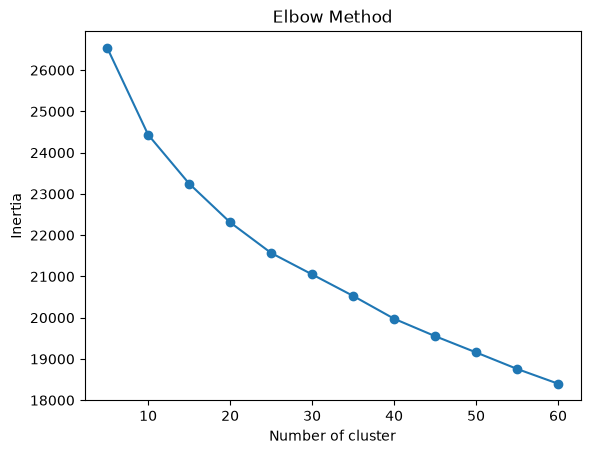

In [13]:
# Elbow method (quantitative)
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []

cluster_range = range(5,61,5)

for k in cluster_range:
    model_km = KMeans(
        n_clusters=k, 
        random_state=42, 
        n_init=10)
    model_km.fit(skill_embeddings)
    inertias.append(model_km.inertia_)

plt.plot(cluster_range, inertias, marker= "o")
plt.xlabel("Number of cluster")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

Look for the point where adding more clusters gives smaller improvement.
Here we do not see a _sharp elbow_ so no obvious turining point. It is common with text embeddings because clusters are naturally continuous. 

Here we look at the rate of improvement (previous inertia - current inertia)/previous inertia.

The point where improvements become consistently small is the "elbow".

Here we see at k=30, there is smaller improvement. 
Since we are looking for "discovering meaningful lavor-market skill group", K=10 is too broad, K=30 probably good balance, K=60 is too fragmented. 

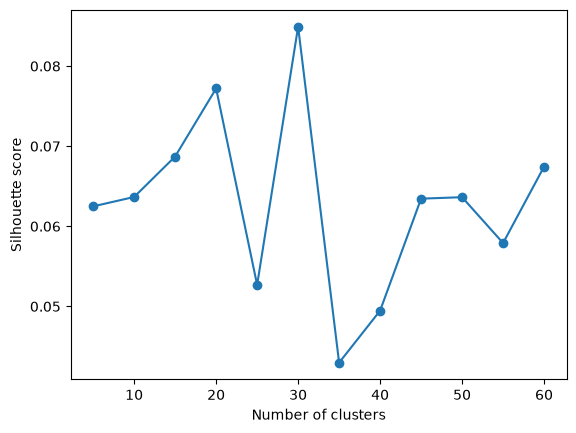

In [14]:
# Silhouette score (quality)
# Measures how well-separated clusters are. higher = better

from sklearn.metrics import silhouette_score

scores = []

for k in range(5,61,5):
    model_km = KMeans(
        n_clusters = k,
        random_state=42, # reproducibility
        n_init=10 #runs multiple initializations and chooses the best one
    )
    lables = model_km.fit_predict(skill_embeddings)
    
    score = silhouette_score(
        skill_embeddings,
        lables
    )
    
    scores.append(score)
    
plt.plot(cluster_range, scores, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.show()

For text embeddings, silhouette score may not always choose the most meaningful business clusters. Therefore, after metrics, we must inspect cluster contents.

Looking at the silhouette plot:

Best score is around k = 30 (~0.085)
Second good option is k = 20 (~0.077)
k = 60 is lower (~0.067)

so the metrics support, n_clusters = 30, which is consistent with the elbow plot. 

Here we are not clustering for pure ML accuracy.
We want meaningful skill domains:

for Examples:

- Healthcare
- Construction
- Data & AI
- Digital transformation
- Management
- Service

So: too few clusters: 5 clusters, might combine everything:
Technology + Healthcare + Sales

Too many: 100 clusters, creates tiny meaningless groups.

So, we have 2423 skills, for portfolio analysis, we tested _k = 10,15,20,25,30,40,50_
We expect something between 20-40 clusters, so possible final choice could be n_clusters = 30.

## Choosing the number of clusters

Different cluster sizes were evaluated using the elbow method and silhouette score.

The silhouette score was highest around 30 clusters, while the elbow curve showed diminishing improvement after this range.

A 30-cluster solution was selected because it provided a balance between:
- cluster separation
- interpretability of skill groups
- usefulness for labor market analysis

In [15]:
from sklearn.cluster import KMeans

# choosing number of clusters
n_cluster = 30 # for 2423 clusters

# create model
model_km = KMeans( # kmeans 
    n_clusters = n_cluster,
    random_state =  42,
    n_init = 10
)

# fit
skill_clusters = model_km.fit_predict(skill_embeddings)

# add labels
skill_vocaburaly_filtered["cluster"] = skill_clusters

Several cluster sizes were tested using elbow and silhouette methods. A 30-cluster solution provided a balance between cluster separation and interpretability for labor market skill domains.

In [16]:
# creating a table
cluster_summary= (
    skill_vocaburaly_filtered
    .sort_values(["cluster", "frequency"], ascending=[True,False])
    .groupby("cluster")
    .head(10)
)

cluster_summary

,skill,frequency,cluster
27,HMS,402,0
138,Maritim,115,0
160,Offshore,100,0
315,Sjøfart,53,0
383,Flyplass,41,0
...,...,...,...
208,Kundeoppfølging,78,29
241,Internkontroll,67,29
244,Varehåndtering,66,29
245,CRM,66,29


This table shows the "first inspection of our 30 skill clusters". Here:
- cluster means the group assigned by KMeans
- skill means a skill inside that group
- frequency is how many job postings contain that skill

cluster 0 contains HMS, Maritim, Offshore, Sjæfart, Flyplass, so algorithm found them are semantically similar.

It can be interpreted as: Cluster 0 → Maritime / Offshore / Safety
Cluster 29 → Business operations / Customer management

### interpretation stage

The algorithm created 30 groups. Now we need to understand what those groups represent.
We only need to find the clusters relevant to the project:

AI
Data
Digital transformation
Technology
Future skills

Now we inspect all cluster contents and let the semantic grouping reveal themes.
### Find technology-related clusters

Inspect clusters and identify themes

Raw skills
(10,997)
      ↓
Filter meaningful skills
(2,423)
      ↓
Semantic clustering
(30 clusters)
      ↓
Interpret clusters
      ↓
Create skill domains
      ↓
Analyze future skills

Skill domains were discovered using semantic clustering of job-posting skills, rather than predefined keyword categories.

Pipeline:
Skills (10,997)
        ↓
Semantic clustering
        ↓
Skill domains (for organization)
        ↓
Individual important skills inside domains
        ↓
Jobs requiring those skills
        ↓
Career insights

1. Which jobs need these skills?
for example. Skill: Python

Jobs:
- Developer
- Data Analyst
- Engineer
- Consultant

2. How demanded are they?
Exmaple:
Python:
200 job postings

SQL:
350 job postings

Power BI:
150 job postings

3. Where are they demanded?
Oslo:
highest demand

Trondheim:
high demand

Stavanger:
some demand

4. Are they increasing/future relevant?

(If we had time data, we could analyze trends.)

The stronger story is:

Skills
 ↓
Skill vocabulary
 ↓
Embeddings
 ↓
Semantic clusters
 ↓
Identify AI/Data/Digital skill domains
 ↓
Extract actual skills
 ↓
Analyze jobs requiring them

### Create a cluster interpretation table

In [17]:
# creating a review format
for cluster in range(30):
    print("\n============")
    print(f"CLUSTER{cluster}")
    
    skills = cluster_summary[
        cluster_summary["cluster"] == cluster
    ]["skill"].tolist()
    
    print(", ".join(skills))


CLUSTER0
HMS, Maritim, Offshore, Sjøfart, Flyplass, Subsea, Ferskvare, Båt, Havbruk, Luftfart

CLUSTER1
Autorisasjon, Politi, Forsvar, Forsvaret, Jurist, Risikovurdering, Informasjonssikkerhet, IT-sikkerhet, Juridisk, Risikostyring

CLUSTER2
Helse, Sykepleier, Helsefagarbeider, Helsefag, Poliklinikk, Kommunal helse, Medikamenthåndtering, Legemiddelhåndtering, Hjelpepleier, Hjemmesykepleie

CLUSTER3
Salgsmedarbeider, Miljøarbeider, Barne- og ungdomsarbeider, Fagarbeider, Fysisk arbeid, Sosialt arbeid, Husarbeid, Nattarbeid, Turnusarbeid, Klinisk arbeid

CLUSTER4
Kundeservice, Service, Hjemmetjeneste, Servering, Serviceinnstilt, Brukerstøtte, Serviceinnstilling, Gjesteservice, Servicetekniker, hjemmetjeneste

CLUSTER5
Personalansvar, Administrasjon, Assistent, Ledelse, Personlig assistent, Seniorrådgiver, Forvaltning, HR, Servitør, Renholder

CLUSTER6
Omsorg, Leder, Sykehus, Barn, Vedlikehold, Barnehage, Pleie, Renhold, Varepåfylling, Matlaging

CLUSTER7
Elektro, Elektriker, Energi, Olj

semantic clustering:
Group skills by meaning, then inspect whether AI/data/digital skills naturally appear together.

## Skill Cluster Interpretation

The clustering algorithm groups skills based on semantic similarity.
Each cluster is manually interpreted to identify broader skill domains.

These domains are later used to identify future-oriented skills such as:
- Data
- AI
- Digital transformation
- Automation
- Technology


The clustering found:

AI appears naturally in Cluster 22
Data skills cluster together in Cluster 9
Digital transformation appears in Cluster 8

# 6. Creating Future Skill Domains

The semantic clusters were manually interpreted to identify skill domains related to AI, digitalization, and future labor market needs.

These domains are used to organize individual skills for further analysis.

In [18]:
# create the mapping

# lables from out manual interpretation of the clusters. we as analysts assigned meaningful names
skill_domains = {
    1: "Cybersecurity & Information Security",
    8: "Digitalization & ICT",
    9: "Data & Analytics",
    22: "AI, Software & Automation",
    25: "Analysis & Reporting",
    29: "Business Systems & CRM"
}

# convert to dataframe
skill_domain_mapping = pd.DataFrame(
    skill_domains.items(),
    columns = ["cluster", "skill_domains"]
)
skill_domain_mapping

,cluster,skill_domains
0,1,Cybersecurity & Information Security
1,8,Digitalization & ICT
2,9,Data & Analytics
3,22,"AI, Software & Automation"
4,25,Analysis & Reporting
5,29,Business Systems & CRM


In [20]:
# connect clusters back to skills
future_skills = skill_vocaburaly_filtered.merge(
    skill_domain_mapping,
    on="cluster",
    how="inner"
)
future_skills.head()

,skill,frequency,cluster,skill_domains
0,Analyse,367,25,Analysis & Reporting
1,BPA,246,25,Analysis & Reporting
2,Digitalisering,186,8,Digitalization & ICT
3,Avdelingsleder,182,29,Business Systems & CRM
4,Dokumentasjon,177,8,Digitalization & ICT


now we connected skill, cluster and skill domain.

_Issue:_
We see that BPA (Brukerstyrt personling assistent) is in "Analysis and Reporting" cluster which is not belong there. This happened because cluster 25 is not pure "future skill" cluster. It mixes analysis/reporting skills, healthcare/social skills, and administration skills. 
This is a limitation in clustering. The model grouped them semantically, but not perfectly. 
So, we should not use the enitre cluster blindly. Instead, we create a "future skills filter" inside these domains. 

This is normal in real projects:

- Machine learning discovers groups.
- Analyst validates and cleans the result.

In [21]:
# final dataset, only relevant skills
# see all skills grouped by domain
future_skills.groupby("skill_domains")["skill"].apply(list)

skill_domains
AI, Software & Automation               [Teknologi, Mekaniker, Automatisering, Teknisk...
Analysis & Reporting                    [Analyse, BPA, Rapportering, Forskning, Kvalit...
Business Systems & CRM                  [Avdelingsleder, Brukeroppfølging, ERP, Matser...
Cybersecurity & Information Security    [Autorisasjon, Politi, Forsvar, Forsvaret, Jur...
Data & Analytics                        [Dataanalyse, SQL, Dataplattform, Datamodeller...
Digitalization & ICT                    [Digitalisering, Dokumentasjon, Kommunikasjon,...
Name: skill, dtype: object

Clusters were manually interpreted after unsupervised learning. Some overlap between domains exists because job skills are naturally interdisciplinary

In [22]:
future_domain_summary = (
    future_skills
    .groupby("skill_domains")["frequency"]
    .sum()
    .sort_values(ascending=False)
)

future_domain_summary

skill_domains
Business Systems & CRM                  3119
Analysis & Reporting                    2954
AI, Software & Automation               2036
Cybersecurity & Information Security    1500
Digitalization & ICT                    1166
Data & Analytics                         345
Name: frequency, dtype: int64

<Axes: title={'center': 'Demand for Future Skill Domains'}, ylabel='skill_domains'>

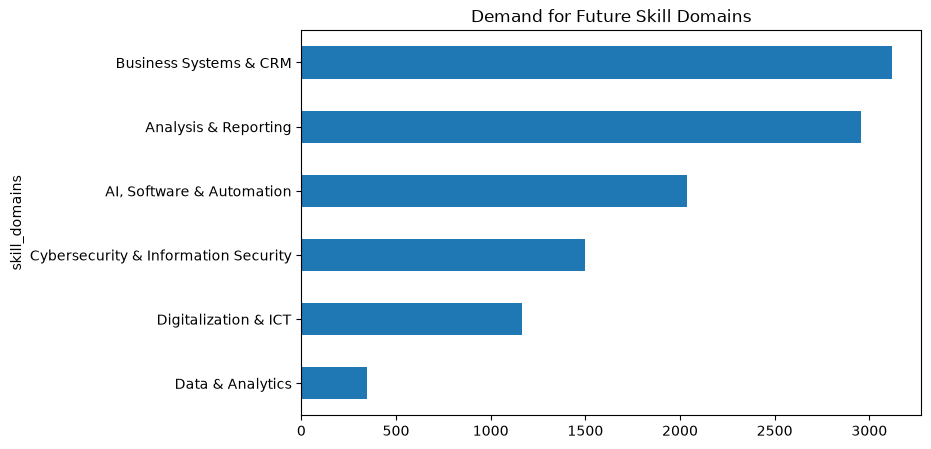

In [23]:
future_domain_summary.sort_values().plot(
    kind="barh",
    figsize=(8,5),
    title="Demand for Future Skill Domains"
)

In [24]:
future_skills[
    future_skills["skill_domains"] == "Data & Analytics"
].sort_values(
    "frequency",
    ascending=False
)

,skill,frequency,cluster,skill_domains
25,Dataanalyse,79,9,Data & Analytics
76,SQL,39,9,Data & Analytics
79,Dataplattform,38,9,Data & Analytics
82,Datamodellering,37,9,Data & Analytics
132,Datasenter,19,9,Data & Analytics
201,Databaser,13,9,Data & Analytics
248,Datakvalitet,10,9,Data & Analytics
250,Datavarehus,10,9,Data & Analytics
275,Geodata,9,9,Data & Analytics
291,Dataanalytiker,8,9,Data & Analytics


In [25]:
future_skills.sort_values(
    "frequency",
    ascending=False
).head(30)

,skill,frequency,cluster,skill_domains
0,Analyse,367,25,Analysis & Reporting
1,BPA,246,25,Analysis & Reporting
2,Digitalisering,186,8,Digitalization & ICT
3,Avdelingsleder,182,29,Business Systems & CRM
4,Dokumentasjon,177,8,Digitalization & ICT
5,Kommunikasjon,174,8,Digitalization & ICT
6,Teknologi,164,22,"AI, Software & Automation"
7,Autorisasjon,155,1,Cybersecurity & Information Security
8,Rapportering,142,25,Analysis & Reporting
9,Mekaniker,139,22,"AI, Software & Automation"


In [26]:
# Create a dataset only from these 4 clusters:
technology_skills = future_skills[
    future_skills["cluster"].isin([1,8,9,22,25,29])
]

technology_skills.sort_values(
    "frequency",
    ascending=False
).head(30)

,skill,frequency,cluster,skill_domains
0,Analyse,367,25,Analysis & Reporting
1,BPA,246,25,Analysis & Reporting
2,Digitalisering,186,8,Digitalization & ICT
3,Avdelingsleder,182,29,Business Systems & CRM
4,Dokumentasjon,177,8,Digitalization & ICT
5,Kommunikasjon,174,8,Digitalization & ICT
6,Teknologi,164,22,"AI, Software & Automation"
7,Autorisasjon,155,1,Cybersecurity & Information Security
8,Rapportering,142,25,Analysis & Reporting
9,Mekaniker,139,22,"AI, Software & Automation"


Skill clusters
        ↓
Identify technology-related clusters
        ↓
Use job titles to validate skills
        ↓
Rank individual skills

We now add job title validation

Create skill + job relationship

In [27]:
# find variables and dataframe
%whos DataFrame

Variable                    Type         Data/Info
--------------------------------------------------
cluster_summary             DataFrame    Shape: (289, 3)
future_skills               DataFrame    Shape: (500, 4)
skill_domain_mapping        DataFrame    Shape: (6, 2)
skill_vocaburaly            DataFrame    Shape: (10997, 2)
skill_vocaburaly_filtered   DataFrame    Shape: (2423, 3)
skills_jobs_df              DataFrame    Shape: (95324, 7)
technology_skills           DataFrame    Shape: (500, 4)


In [28]:
skill_job_analysis = skills_jobs_df[
    ["skill", "title", "category", "occupation"]
]

# Connect future skills to jobs

future_skill_jobs = future_skills.merge(
    skill_job_analysis,
    on="skill",
    how="left"
)

future_skill_jobs.head()

,skill,frequency,cluster,skill_domains,title,category,occupation
0,Analyse,367,25,Analysis & Reporting,Har du lyst til å bidra til å utvikle Forsvare...,Not classified,Not classified
1,Analyse,367,25,Analysis & Reporting,Rådgiver/seniorrådgiver strategi,Not classified,Not classified
2,Analyse,367,25,Analysis & Reporting,Vil du bygge kompetanse innen risiko og person...,"Jurister og advokater, Finans- og investerings...",", , ,"
3,Analyse,367,25,Analysis & Reporting,LEAN / Forbedringsleder,"Sivilingeniører (industri og produksjon), Lean...",Not classified
4,Analyse,367,25,Analysis & Reporting,Vil du jobbe med merverdiavgift i et sterkt fa...,"Økonom, Økonom, Rådgivere/forskere, samfunnsøk...",Not classified


In [29]:
# Inspect one domain
data_ai_jobs = future_skill_jobs[
    future_skill_jobs["skill_domains"]
    .isin([
        "Data & Analytics",
        "AI, Software & Automation"
    ])
]

data_ai_jobs["category"].value_counts().head(20)

category
Dataingeniør, Dataingeniør, Sivilingeniører (elektronikk)                            36
Elektriker, Elektriker, Elektrikere                                                  34
Dataanalytiker, Dataanalytiker, Systemanalytikere/-arkitekter                        25
Driftstekniker, Driftstekniker, Andre ingeniører                                     24
Mekaniker, Mekaniker, Bilmekanikere                                                  22
Anleggsmaskinfører, Anleggsmaskinfører, Anleggsmaskinførere                          20
Tekniker, Tekniker, Andre ingeniører                                                 19
Maskiningeniør, Maskiningeniør, Maskiningeniører                                     19
Servicetekniker, Servicetekniker, Andre ingeniører                                   18
Forsker datavitenskap, Forsker datavitenskap, Systemanalytikere/-arkitekter          18
Prosjektleder, Prosjektleder, Andre administrative ledere                            16
Bilmekaniker, Bilmekani

It shows: Which occupations/jobs are connected to AI/data skills?

#### skill → relevant occupation frequency
A skill is more "future technology relevant" if it appears frequently in technology occupations.

In [30]:
domain_job_distribution = (
    future_skill_jobs
    .groupby(["skill_domains", "category"])
    .size()
    .reset_index(name="job_count")
    .sort_values(
        ["skill_domains", "job_count"],
        ascending=[True, False]
    )
)

domain_job_distribution.head(30)

,skill_domains,category,job_count
275,"AI, Software & Automation","Elektriker, Elektriker, Elektrikere",33
267,"AI, Software & Automation","Driftstekniker, Driftstekniker, Andre ingeniører",23
574,"AI, Software & Automation","Mekaniker, Mekaniker, Bilmekanikere",22
109,"AI, Software & Automation","Anleggsmaskinfører, Anleggsmaskinfører, Anlegg...",20
966,"AI, Software & Automation","Tekniker, Tekniker, Andre ingeniører",19
545,"AI, Software & Automation","Maskiningeniør, Maskiningeniør, Maskiningeniører",18
797,"AI, Software & Automation","Servicetekniker, Servicetekniker, Andre ingeni...",18
181,"AI, Software & Automation","Bilmekaniker, Bilmekaniker, Bilmekanikere",16
697,"AI, Software & Automation","Prosjektleder, Prosjektleder, Andre administra...",14
933,"AI, Software & Automation","Systemanalytikere/-arkitekter, Systemingeniør,...",14


In [31]:
skill_job_profile = (
    future_skill_jobs
    .groupby("skill")
    .agg(
        total_jobs=("category", "count"),
        unique_categories=("category", "nunique")
    )
    .sort_values(
        "total_jobs",
        ascending=False
    )
)

skill_job_profile.head(30)

,total_jobs,unique_categories
skill,,
Analyse,367,296
BPA,246,40
Digitalisering,186,160
Avdelingsleder,182,104
Dokumentasjon,177,90
Kommunikasjon,174,136
Teknologi,164,148
Autorisasjon,155,45
Rapportering,142,117


In [33]:
tech_skills = future_skills[
    future_skills["skill_domains"].isin(future_tech_domains)
]


tech_skill_rank = (
    tech_skills
    .groupby("skill")
    .agg(
        skill_frequency=("frequency","sum"),
        job_categories=("category","nunique"),
        occupations=("occupation","nunique")
    )
    .sort_values(
        ["skill_frequency","occupations"],
        ascending=False
    )
)

tech_skill_rank.head(30)

NameError: name 'future_tech_domains' is not defined

Correction:

occupation is no longer used because its coverage is too poor.
Skill frequencies are based on unique job_id, not row counts.
The frequency >= 5 filter is used only for exploratory clustering, so rare but meaningful AI skills are not lost from the final analysis.
Embeddings are normalized before semantic clustering.
KMeans is clearly treated as exploratory, not as the final future-skill classifier.
The noisy manual mapping such as BPA → Analysis & Reporting and Mekaniker → AI & Software is removed from the final methodology.
The final method maps all 10,997 NAV skills against all ESCO skills first, and only afterward checks whether the matched ESCO concept has ESCO's official digital label. This is important because otherwise non-digital skills would be forced to match some digital skill.
Norwegian and English ESCO labels are both used. ESCO officially supports Norwegian and English among its multilingual language packs.
ESCO's digitalSkillsCollection is specifically designed for this purpose and contains 1,201 concepts labelled as digital.
Semantic-match quality is validated before choosing a cutoff rather than inventing an arbitrary threshold.
Final job/category/city counts use job_id.nunique(), preventing jobs with several digital skills from being counted multiple times.

The notebook now has a much clearer pipeline:

NAV job skills
      ↓
Full skill vocabulary
      ↓
Exploratory embeddings + clustering
      ↓
Conclusion: clusters contain useful structure but also noise
      ↓
All NAV skills
      ↓
Semantic matching to ALL ESCO skills
      ↓
Official ESCO digital label
      ↓
Validated digital skills
      ↓
Job title / category / city
      ↓
Top skills to learn + jobs requiring them